## Função para diminuir o número de amostras originais de 100 para 50 coletando de forma intercalada

In [14]:
import pandas as pd

df = pd.read_csv("/mnt/HD/Mestrado/Dissertacao/compressive_sensing/compressed_data_classification/data/raw/data_half_slice_per_4.csv")

fixed_colum = df.iloc[:, [0]] # Todas as linhas, coluna de índice zero
sampled_colums = df.iloc[:, 1::2] # Da coluna 1 de duas em duas
df_sampled = pd.concat([fixed_colum, sampled_colums], axis=1).reset_index(drop=True)

print(f"Colunas_originais: {df.shape[1]}")
print(f"Colunas amostradas: {df_sampled.shape[1]}")
print(df_sampled.head())

df_sampled.to_csv("/mnt/HD/Mestrado/Dissertacao/compressive_sensing/compressed_data_classification/data/processed/half_slice_per_4/data_sampled_2_dot_5_khz.csv", index=False)

Colunas_originais: 101
Colunas amostradas: 51
         s1        s2        s4        s6        s8       s10       s12  \
0 -0.812603 -0.774404 -0.689000 -0.592731 -0.487113 -0.373814 -0.254619   
1 -0.981451 -0.991552 -0.999990 -0.992658 -0.969671 -0.931392 -0.878424   
2 -0.370116 -0.427717 -0.537635 -0.639074 -0.730434 -0.810275 -0.877337   
3  0.709603  0.752445  0.829063  0.892607  0.942073  0.976682  0.995889   
4  0.122887  0.184959  0.306671  0.423547  0.533744  0.635522  0.727279   

        s14       s16       s18  ...       s82       s84       s86       s88  \
0 -0.131409 -0.006127  0.119253  ... -1.469118 -1.575563 -1.510039 -1.396557   
1 -0.811603 -1.144694 -1.002128  ... -0.154817 -0.432194 -0.785011 -0.872908   
2 -0.930563 -0.969114 -0.992381  ...  1.089944  1.007249  0.915843  0.673938   
3  0.999389  0.987129  0.959301  ... -0.617843 -0.432276 -0.239891 -0.043723   
4  0.807565  0.875116  1.463212  ... -1.192223 -1.195130 -1.150976 -0.639322   

        s90       s92 

## Função para criar dataset de amostras aleatórias usando o pandas (SEM O PHI)

In [15]:
import pandas as pd

df = pd.read_csv("/mnt/HD/Mestrado/Dissertacao/compressive_sensing/compressed_data_classification/data/raw/data_half_slice_per_4.csv")

# 1. Separar a coluna fixa (ex: classe/label)
fixed_column = df.iloc[:, [0]]

# 2. Definir as colunas que representam o sinal (da 1 em diante)
signal_data = df.iloc[:, 1:]

# 3. Selecionar aleatoriamente M colunas (ex: 50 colunas para 50% de amostragem)
# random_state garante que o sorteio seja o mesmo toda vez que rodar
M = 50 
sampled_signal = signal_data.sample(n=M, axis=1, random_state=42)

# 4. IMPORTANTE: Ordenar as colunas pela posição original
# Isso garante que a sequência temporal do sinal não seja embaralhada
sampled_signal = sampled_signal.reindex(sorted(sampled_signal.columns), axis=1)

# 5. Concatenar de volta
df_sampled = pd.concat([fixed_column, sampled_signal], axis=1).reset_index(drop=True)

df_sampled.to_csv("/mnt/HD/Mestrado/Dissertacao/compressive_sensing/compressed_data_classification/data/processed/half_slice_per_4/data_sampled_randomly.csv", index=False)

print(f"Colunas originais: {df.shape[1]}")
print(f"Colunas amostradas aleatoriamente: {df_sampled.shape[1]}")
print(df_sampled.head())

Colunas originais: 101
Colunas amostradas aleatoriamente: 51
         s1       s11       s12       s13       s14       s15       s17  \
0 -0.812603 -0.314838 -0.254619 -0.193396 -0.131409 -0.068904  0.056675   
1 -0.981451 -0.906697 -0.878424 -0.846684 -0.811603 -1.209337 -1.075533   
2 -0.370116 -0.845474 -0.877337 -0.905737 -0.930563 -0.951717 -0.982687   
3  0.709603  0.988235  0.995889  0.999611  0.999389  0.995223  0.975139   
4  0.122887  0.682748  0.727279  0.768939  0.807565  0.843004  1.423687   

        s18        s2       s20  ...       s82       s83       s85       s87  \
0  0.119253 -0.774404  0.377503  ... -1.469118 -1.547196 -1.558646 -1.449147   
1 -1.002128 -0.991552 -0.843759  ... -0.154817 -0.258226 -0.628202 -0.864458   
2 -0.992381 -0.427717 -0.999998  ...  1.089944  1.027743  0.984800  0.763039   
3  0.959301  0.752445  0.916344  ... -0.617843 -0.526098 -0.336748 -0.142088   
4  1.463212  0.184959  1.524807  ... -1.192223 -1.159812 -1.258782 -1.081173   

       

## Função para criar dataset de amostras aleatórias seguindo a metodologia de A

In [ ]:
import pandas as pd
import numpy as np

# Importar A e o dicionário
df = pd.read_csv("/mnt/HD/Mestrado/Dissertacao/compressive_sensing/compressed_data_classification/data/raw/data.csv")
Phi = np.load("/mnt/HD/Mestrado/Dissertacao/compressive_sensing/compressed_data_classification/src/cs/cs_constants/cs_best_result_Phi.npy")

# multiplicar cada linha do dicionário por A para fazer a amostragem
col_names = df.filter(regex=r"^s\d+$").columns

selected_indices = np.argmax(Phi, axis=1)
selected_col_names = col_names[selected_indices].tolist()

# Criar df com a primeira coluna mais as colunas selecionadas por Phi
first_col_name = df.columns[0]
target_col_name = df.columns[-1]
df_final = df[[first_col_name] + selected_col_names + [target_col_name]].copy()
df_final = df_final.reset_index(drop=True)

df_final.to_csv("/mnt/HD/Mestrado/Dissertacao/compressive_sensing/compressed_data_classification/data/processed/data_sampled_with_phi.csv", index=False)
print(df_final.head())

## Juntar os databases das diferentes classes diminuindo o número de amostras de cada classe em n vezes

Dados completos salvos em: /mnt/HD/Mestrado/Dissertacao/compressive_sensing/compressed_data_classification/data/raw/data_half_slice_per_4.csv
         s1        s2        s3        s4        s5        s6        s7  \
0 -0.812603 -0.774404 -0.733149 -0.689000 -0.642133 -0.592731 -0.540990   
1 -0.981451 -0.991552 -0.997740 -0.999990 -0.998294 -0.992658 -0.983104   
2 -0.370116 -0.427717 -0.483631 -0.537635 -0.589518 -0.639074 -0.686108   
3  0.709603  0.752445  0.792318  0.829063  0.862537  0.892607  0.919154   
4  0.122887  0.184959  0.246301  0.306671  0.365831  0.423547  0.479592   

         s8        s9       s10  ...       s92       s93       s94       s95  \
0 -0.487113 -0.431315 -0.373814  ... -1.485103 -1.560167 -1.623929 -1.508587   
1 -0.969671 -0.952411 -0.931392  ... -1.135247 -0.767693 -0.806416 -0.841955   
2 -0.730434 -0.771878 -0.810275  ...  0.185276  0.123207  0.060652 -0.002143   
3  0.942073  0.961274  0.976682  ...  0.221594  0.282386  0.342064  0.400391   
4  0.53

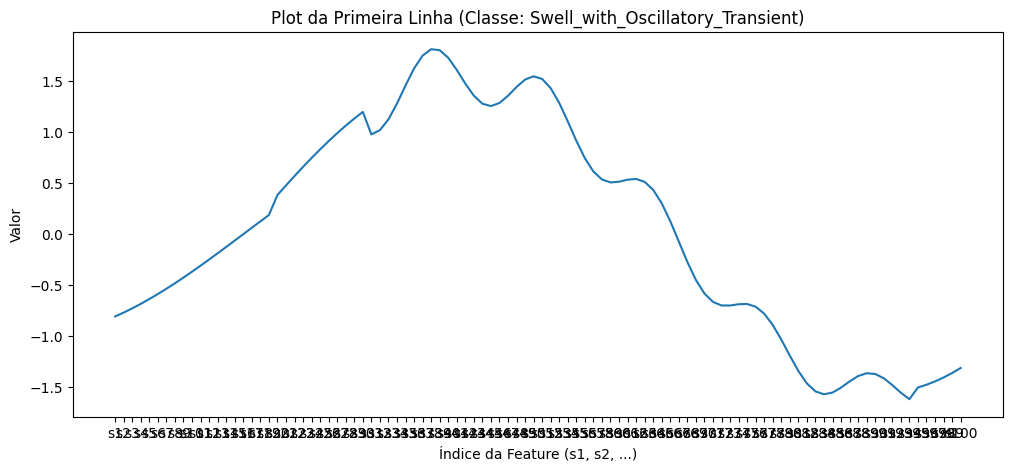

In [13]:
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt

folder = '/mnt/HD/Mestrado/Dissertacao/compressive_sensing/compressed_data_classification/data/raw/by_class'

default_path = os.path.join(folder, '*.csv')

csv_files = glob.glob(default_path) # Retorna uma lista com todos os csv

sufix = '.csv'
y = [os.path.basename(file_path).removesuffix(sufix) for file_path in csv_files]
columns=[f's{i+1}' for i in range(100)]
data = pd.DataFrame()

for file_path in csv_files:
    # Ler o arquivo csv
    csv_data = pd.read_csv(file_path, header=None)
    
    if csv_data.shape[1] != len(columns):
        print(f"AVISO: {os.path.basename(file_path)} tem {csv_data.shape[1]} colunas, esperado {len(columns)}.")
        continue # Pular arquivos com número incorreto de colunas
    
    csv_data.columns = columns
    
    class_name = os.path.basename(file_path).removesuffix(sufix)
    csv_data['target'] = class_name
    
    # dividir o número de 
    slice_lenght = len(csv_data)//4
    csv_data_sliced = csv_data.iloc[:slice_lenght, :]
    
    data = pd.concat([data, csv_data_sliced], axis=0, ignore_index=True)
    
path = '/mnt/HD/Mestrado/Dissertacao/compressive_sensing/compressed_data_classification/data/raw/data_half_slice_per_4.csv'
data.to_csv(path, index=False)
print(f'Dados completos salvos em: {path}')
print(data.head())

# Printando um sinal de amostra
first_line = data.iloc[0]
data_to_plot = first_line.drop('target', errors='ignore')

plt.figure(figsize=(12,5))
plt.plot(data_to_plot)
plt.title(f"Plot da Primeira Linha (Classe: {first_line['target']})")
plt.xlabel("Índice da Feature (s1, s2, ...)")
plt.ylabel("Valor")
plt.show()